In [2]:
import os
import warnings
warnings.simplefilter("ignore")

import torch
import torch.nn.functional as F
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models.feature_extraction import create_feature_extractor
import torch.nn as nn
from torchvision.utils import make_grid
from torchvision.transforms.functional import to_pil_image

from pathlib import Path
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import pairwise_distances, balanced_accuracy_score
from sklearn.metrics import confusion_matrix

from lib.data.utils import Color
from lib.data import (
    ColoredMNISTDataset,
    ColoredMNISTDatasetAblated,
    get_ColoredMNISTDataset_dataloader
)
from lib.models.capacity_constrained_autoencoders import (
    ConfigBetaVAEForImages,
    BetaVAEForImages
)
from lib.models import (
    CVAEFilm,
    AEModelConfig
)
from lib.analysis import tg_mds
from lib.plotting import fig_to_rgba
from lib.data.datasets import Input
from lib.plotting.fonts import montserrat_regular, montserrat_medium, montserrat_bold
from lib import filepaths

device = torch.device("cuda") if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [8]:
color_codes = [Color.RED, Color.GREEN, Color.CYAN, Color.YELLOW, Color.MAGENTA]

""" np.random.seed(44)
pairs_to_ablate = np.c_[np.random.choice(10, len(color_codes), replace=False), range(len(color_codes))]
pairs_to_ablate = [tuple(p) for p in pairs_to_ablate]
display(pd.DataFrame(pairs_to_ablate, columns=["Digit", "Color"])) """

pairs_to_ablate = [
    (2,0),
    (7,1),
    (9,2),
    (3,3),
    (6,4)
]
print(pairs_to_ablate)

train_dataset_ablated = ColoredMNISTDatasetAblated(
    missing_pairs=pairs_to_ablate,
    color_codes=color_codes,
    train=True
)

test_dataset_ablated = ColoredMNISTDatasetAblated(
    missing_pairs=pairs_to_ablate,
    color_codes=color_codes,
    train=False
)


batch_size = 64

train_dataloader = get_ColoredMNISTDataset_dataloader(
    batch_size=batch_size,
    dataset=train_dataset_ablated,
    shuffle=True,
    drop_last=True
)

test_dataloader = get_ColoredMNISTDataset_dataloader(
    batch_size=batch_size,
    dataset=test_dataset_ablated,
    shuffle=False,
    drop_last=True
)

[(2, 0), (7, 1), (9, 2), (3, 3), (6, 4)]


In [3]:
w = ResNet50_Weights.DEFAULT
preprocess = w.transforms()
model = resnet50(weights=w)
model.to(device)
model.eval()

model = create_feature_extractor(model, dict(layer1="feat1", layer2="feat2", layer3="feat3"))
f = nn.AdaptiveAvgPool2d((2,2))

@torch.no_grad()
def get_perc_emb(pixel_values):
    out = model(preprocess(pixel_values.to(device)))
    out = {k:f(v).flatten(1).cpu().numpy() for k,v in out.items()}
    return out

In [4]:
# VAE

root = "resources/hippo_dreaming_beta_cvae.pt"
ckpt = torch.load(root, weights_only=False)
cvae = CVAEFilm(
    config=ckpt["config"],
    **ckpt["kwargs"]
)
cvae.load_state_dict(ckpt["state_dict"])
cvae.to(device)
cvae.eval()
cvae.show_number_of_parameters()

# Beta-VAE Limited Capacity (1 Nats)

root = "resources/hippo_dreaming_beta_cvae_limited_capacity_nats1.pt"
ckpt = torch.load(root, weights_only=False)
beta_cvae = BetaVAEForImages(
    config=ckpt["config"]
)
beta_cvae.load_state_dict(ckpt["state_dict"])
beta_cvae.to(device)
beta_cvae.eval()
beta_cvae.show_number_of_parameters()

0.561M / 0.561M
0.561M / 0.561M


In [5]:
@torch.no_grad()
def sample_images(cvae, digit_id: int, color_id: int, n: int, modality=0):
    recs = []
    for _ in range(n):
        rec = cvae.conditional_simulation(
            label_id=digit_id,
            feature_id=color_id
        )
        recs.append(rec)
    recs = torch.stack(recs)

    if modality==0:
        recs = torch.sigmoid(recs) 
    else:
        recs = torch.clip(recs, 0, 1)
    return recs

@torch.no_grad()
def get_embedding(cvae, batch):
    cvae.eval()
    batch.to(device)
    sem_embed = cvae.sem_embeddings(batch.label_ids)
    feat_embed = cvae.feat_embeddings(batch.feature_ids)
    mu, _ = cvae.encode(batch.pixel_values)
    return mu.flatten(1), sem_embed, feat_embed

@torch.no_grad()
def decode(cvae, z, e_s, e_c, modality=0):
    z = z.view(-1, *cvae.hidden_shape).to(device)
    e_s = e_s.view(-1, *cvae.cond_hidden_shape).to(device)
    e_c = e_c.view(-1, *cvae.cond_hidden_shape).to(device)
    reconstructed = cvae.decode(z, e_s, e_c) 

    if modality==0:
        reconstructed = torch.sigmoid(reconstructed) 
    else:
        reconstructed = torch.clip(reconstructed, 0, 1)
    return reconstructed

In [6]:
# ---------- 1) Utilities ----------
def to_luminance_Y(x):  # x: (N,3,H,W), in [0,1]
    r, g, b = x[:,0:1], x[:,1:2], x[:,2:3]
    return 0.299*r + 0.587*g + 0.114*b  # (N,1,H,W)

def l2_normalize_per_image(x, eps=1e-8):
    n = x.flatten(1).norm(dim=1, keepdim=True).clamp_min(eps)
    return x / n.view(-1,1,1,1)

def sobel_mag(x1):  # x1: (N,1,H,W), float
    kx = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=x1.dtype, device=x1.device).view(1,1,3,3)
    ky = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=x1.dtype, device=x1.device).view(1,1,3,3)
    gx = F.conv2d(x1, kx, padding=1)
    gy = F.conv2d(x1, ky, padding=1)
    mag = torch.sqrt(gx*gx + gy*gy)
    return l2_normalize_per_image(mag)

In [ ]:
n = 20
nsim = 100

feature_maps_list = []
for pair in tqdm(pairs_to_ablate):
    feature_maps = {k:dict(original=[], reconstructed=[], recombined=[], simulated=[]) for k in ["feat1", "feat2", "feat3"]}

    digit, color = pair[0], pair[1]

    for i in range(nsim):
        samples_table = test_dataloader.dataset.data_table.query(f"label=={digit}").sample(n, random_state=442+i)
        batch = Input(
            pixel_values=torch.stack([test_dataset_ablated[i][0] for i in samples_table.index]),
            label_ids=torch.stack([test_dataset_ablated[i][1] for i in samples_table.index]),
            feature_ids=torch.stack([test_dataset_ablated[i][2] for i in samples_table.index])
        )
        batch.to(device)

        z, e_s, e_c = get_embedding(cvae, batch)

        reconstructed = decode(cvae, z, e_s, e_c)

        with torch.no_grad():
            z, _ = cvae.encode(batch.pixel_values)
            z = z.flatten(1)
            e_s = cvae.sem_embeddings(torch.tensor(digit, device=device)).repeat(n, 1)
            e_c = cvae.feat_embeddings(torch.tensor(color, device=device)).repeat(n, 1)

        recombined = decode(cvae, z, e_s, e_c)

        simulated = sample_images(cvae, digit, color, n)
        
        def transform(x):
            x = to_luminance_Y(x)
            x = sobel_mag(x)
            return x.repeat(1,3,1,1)

        original_ = transform(batch.pixel_values)
        reconstructed_ = transform(reconstructed)
        recombined_ = transform(recombined)
        simulated_ = transform(simulated)
        for k in feature_maps:
            feature_maps[k]["original"].append(get_perc_emb(original_)[k])
            feature_maps[k]["reconstructed"].append(get_perc_emb(reconstructed_)[k])
            feature_maps[k]["recombined"].append(get_perc_emb(recombined_)[k])
            feature_maps[k]["simulated"].append(get_perc_emb(simulated_)[k])

    feature_maps_list.append(feature_maps)

100%|██████████| 5/5 [08:32<00:00, 102.52s/it]


In [ ]:
reduce = lambda x: x.mean(axis=0)

fig, axes = plt.subplots(2,3, figsize=(10,6))
axes = axes.flatten()
titles = ["-".join([str(p[0]), str(p[1])]) for p in pairs_to_ablate]
colors = ["#FF714B", "#C71E64", "#4D2D8C"]
labels=["Original", "Cortical \nReconstruction", "Episodic \nRecombination", "Cortical \nSimulation"]

for i in range(5):
    ax = axes[i]

    feature_maps = feature_maps_list[i]

    ###
    
    dataset = feature_maps["feat3"]
    centroids = {k:np.vstack([reduce(x) for x in dataset[k]]) for k in dataset}
    x = np.vstack(list(centroids.values()))

    ###

    rho = pairwise_distances(x, metric="cosine")
    df_mds = pd.DataFrame(tg_mds(rho, 2))
    df_mds.columns = ["MDS Dim 1", "MDS Dim 2"]
    df_mds["Label"] = np.repeat(labels, nsim)

    ###
    df_mds = df_mds[df_mds["Label"]!="Original"]

    g = sns.scatterplot(
        data=df_mds,
        x="MDS Dim 1",
        y="MDS Dim 2",
        hue="Label",
        s=100, 
        palette="rocket",
        edgecolor="black",
        alpha=0.8,
        ax=ax
    )
    ax.legend_.remove()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.set_title(titles[i])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].axis("off")
handles, labels = g.get_legend_handles_labels()

axes[-1].legend(handles, labels, loc="center", frameon=False, labelspacing=1.2)

In [29]:
fig.savefig("visuals/recomb_mds.pdf")

In [48]:
n = 20
nsim = 500

feature_maps = dict(original=[], reconstructed=[], recombined=[], simulated=[])
for pair in tqdm(pairs_to_ablate):

    digit, color = pair[0], pair[1]

    for i in range(nsim):
        samples_table = test_dataloader.dataset.data_table.query(f"label=={digit}").sample(n, random_state=442+i)
        batch = Input(
            pixel_values=torch.stack([test_dataset_ablated[i][0] for i in samples_table.index]),
            label_ids=torch.stack([test_dataset_ablated[i][1] for i in samples_table.index]),
            feature_ids=torch.stack([test_dataset_ablated[i][2] for i in samples_table.index])
        )
        batch.to(device)

        z, e_s, e_c = get_embedding(cvae, batch)

        reconstructed = decode(cvae, z, e_s, e_c)

        with torch.no_grad():
            z, _ = cvae.encode(batch.pixel_values)
            z = z.flatten(1)
            e_s = cvae.sem_embeddings(torch.tensor(digit, device=device)).repeat(n, 1)
            e_c = cvae.feat_embeddings(torch.tensor(color, device=device)).repeat(n, 1)

        recombined = decode(cvae, z, e_s, e_c)

        simulated = sample_images(cvae, digit, color, n)

        def transform(x):
            x = to_luminance_Y(x)
            x = sobel_mag(x)
            return x
        
        original_ = transform(batch.pixel_values).cpu()
        reconstructed_ = transform(reconstructed).cpu()
        recombined_ = transform(recombined).cpu()
        simulated_ = transform(simulated).cpu()

        feature_maps["original"].append(original_.flatten(1))
        feature_maps["reconstructed"].append(reconstructed_.flatten(1))
        feature_maps["recombined"].append(recombined_.flatten(1))
        feature_maps["simulated"].append(simulated_.flatten(1))

100%|██████████| 5/5 [02:47<00:00, 33.55s/it]


In [49]:
scores = []
for i in range(len(feature_maps["original"])):
    seed = feature_maps["original"][i]
    score = [pairwise_distances(seed, feature_maps[target][i], metric="euclidean").mean() for target in ["reconstructed", "recombined", "simulated"]]
    scores.append(score)
scores = np.array(scores)
experiment_id = np.repeat(range(5), nsim)

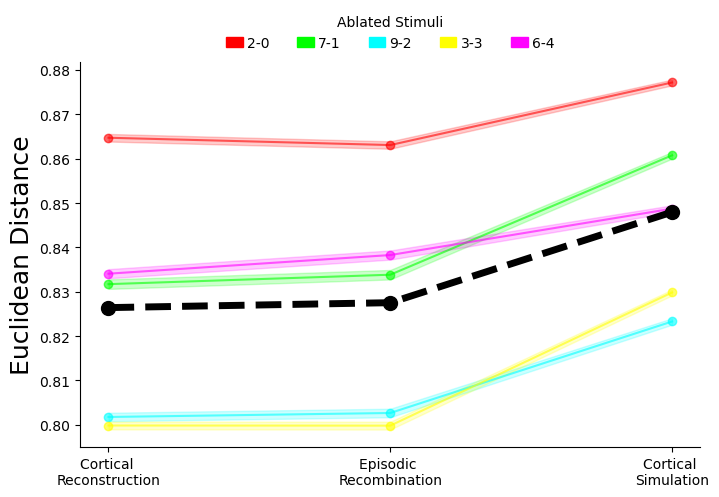

In [50]:
fig, ax = plt.subplots(1, figsize=(8,5))
labels = ["-".join([str(p[0]), str(p[1])]) for p in pairs_to_ablate]
colors = color_codes # ["#5D2F77", "#E45A92", "#415E72", "#F25912", "#FF0066"]

means = []
for i in range(5):
    s = scores[experiment_id==i]

    mean = s.mean(axis=0)
    se = s.std(axis=0)/np.sqrt(s.shape[0])

    ax.plot(range(3), mean, "o-", alpha=0.6, label=labels[i], color=colors[i])
    ax.fill_between(range(3), mean-se, mean+se, alpha=0.2, color=colors[i])

    means.append(mean)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xticks(
    ticks=range(3), 
    labels=["Cortical \nReconstruction", "Episodic \nRecombination", "Cortical \nSimulation"], 
)

ax.set_ylabel("Euclidean Distance", fontsize=18)

leg = ax.legend(
    handles=[Patch(color=v, label=k) for k,v in zip(labels, colors)],
    loc="lower center",
    ncol=5,
    handlelength=1.2,
    handletextpad=0.3,
    columnspacing=2.0,
    bbox_to_anchor=(.5, 1),
    frameon=False
)

leg.set_title("Ablated Stimuli")

s = np.vstack(means)
mean = s.mean(axis=0)
se = s.std(axis=0)/np.sqrt(s.shape[0])
ax.plot(range(3), mean, "o-", color="black", linewidth=5, markersize=10, linestyle="dashed")

In [51]:
fig.savefig("visuals/recomb_euclidean.pdf")

In [42]:
modality = 1
random_seed = 442

images = []

for i in range(len(pairs_to_ablate)):

    pair = pairs_to_ablate[i]

    digit, color = pair[0], pair[1]

    samples_table = test_dataloader.dataset.data_table.query(f"label=={digit}").groupby("color_id").sample(1, random_state=random_seed)

    batch = Input(
        pixel_values=torch.stack([test_dataset_ablated[i][0] for i in samples_table.index]),
        label_ids=torch.stack([test_dataset_ablated[i][1] for i in samples_table.index]),
        feature_ids=torch.stack([test_dataset_ablated[i][2] for i in samples_table.index])
    )

    z, e_s, e_c = get_embedding(cvae, batch)

    reconstructed = decode(cvae, z, e_s, e_c, modality=modality)

    with torch.no_grad():
        z, _ = cvae.encode(batch.pixel_values)
        z = z.flatten(1)
        e_s = cvae.sem_embeddings(torch.tensor(digit, device=device)).repeat(4, 1)
        e_c = cvae.feat_embeddings(torch.tensor(color, device=device)).repeat(4, 1)

    recombined = decode(cvae, z, e_s, e_c, modality=modality)

    simulated = sample_images(cvae, digit, color, 4, modality=modality)

    # VISUALS #
    k = 4

    fig, axes = plt.subplots(4,1)

    ax = axes[0]
    grid = make_grid(batch.pixel_values[:k], nrow=k, padding=2)
    ax.imshow(to_pil_image(grid))

    ax = axes[1]
    grid = make_grid(reconstructed[:k], nrow=k, padding=2)
    ax.imshow(to_pil_image(grid))

    ax = axes[2]
    grid = make_grid(recombined[:k], nrow=k, padding=2)
    ax.imshow(to_pil_image(grid))

    ax = axes[3]
    grid = make_grid(simulated[:k], nrow=k, padding=2)
    ax.imshow(to_pil_image(grid))

    for ax in axes:
        ax.axis("off")

    plt.tight_layout(pad=0.)

    image = fig_to_rgba(fig)
    images.append(image)

    plt.close(fig)

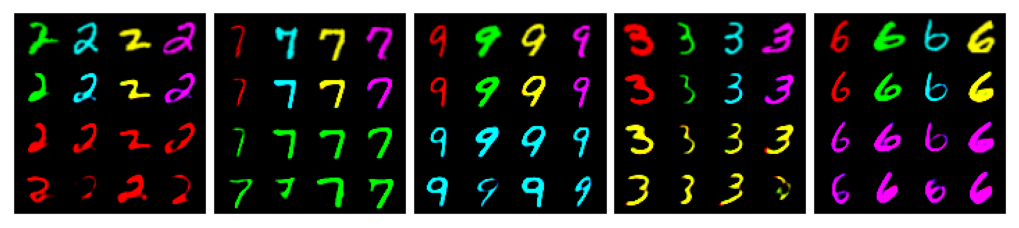

In [43]:
fig, axes = plt.subplots(1,5, figsize=(10,5))
for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.axis("off")
plt.tight_layout(pad=0.)

In [44]:
fig.savefig("visuals/recomb-max_capacity_sim.pdf", dpi=600)

In [45]:
modality = 1
random_seed = 442

images = []

for i in range(len(pairs_to_ablate)):

    pair = pairs_to_ablate[i]

    digit, color = pair[0], pair[1]

    samples_table = test_dataloader.dataset.data_table.query(f"label=={digit}").groupby("color_id").sample(1, random_state=random_seed)

    batch = Input(
        pixel_values=torch.stack([test_dataset_ablated[i][0] for i in samples_table.index]),
        label_ids=torch.stack([test_dataset_ablated[i][1] for i in samples_table.index]),
        feature_ids=torch.stack([test_dataset_ablated[i][2] for i in samples_table.index])
    )

    z, e_s, e_c = get_embedding(beta_cvae, batch)

    reconstructed = decode(beta_cvae, z, e_s, e_c, modality=modality)

    with torch.no_grad():
        z, _ = beta_cvae.encode(batch.pixel_values)
        z = z.flatten(1)
        e_s = beta_cvae.sem_embeddings(torch.tensor(digit, device=device)).repeat(4, 1)
        e_c = beta_cvae.feat_embeddings(torch.tensor(color, device=device)).repeat(4, 1)

    recombined = decode(beta_cvae, z, e_s, e_c, modality=modality)

    # VISUALS #
    k = 4

    fig, axes = plt.subplots(3,1, figsize=(5,3))

    ax = axes[0]
    grid = make_grid(batch.pixel_values[:k], nrow=k, padding=2)
    ax.imshow(to_pil_image(grid))

    ax = axes[1]
    grid = make_grid(reconstructed[:k], nrow=k, padding=2)
    ax.imshow(to_pil_image(grid))

    ax = axes[2]
    grid = make_grid(recombined[:k], nrow=k, padding=2)
    ax.imshow(to_pil_image(grid))

    for ax in axes:
        ax.axis("off")

    plt.tight_layout(pad=0.)

    image = fig_to_rgba(fig)
    images.append(image)

    plt.close(fig)

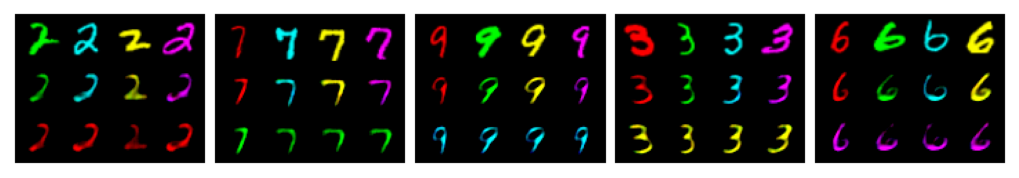

In [46]:
fig, axes = plt.subplots(1,5, figsize=(10,5))
for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.axis("off")
plt.tight_layout(pad=0.)

In [47]:
fig.savefig("visuals/recomb-low_capacity_sim.pdf", dpi=600)